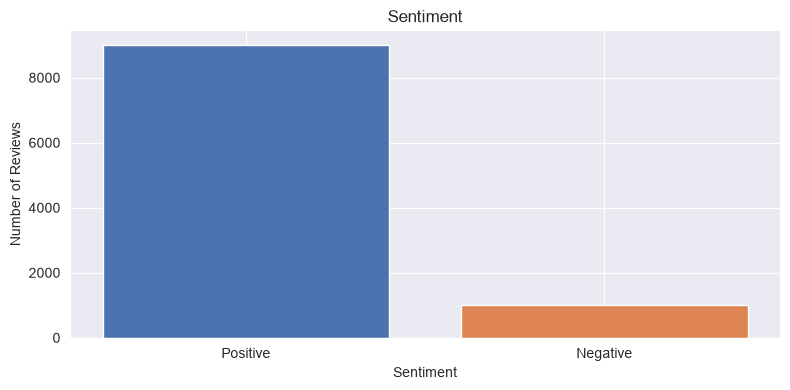

sentiment
positive    9000
negative    1000
Name: count, dtype: int64
sentiment
negative    1000
positive    1000
Name: count, dtype: int64
['positive']
['positive']
['negative']
SVM Accuracy: 84.09%
Decision Tree Accuracy: 66.36%
Naive Bayes Accuracy: 63.48%
Logistic Regression Accuracy: 83.03%
Positive F1 Score: 84.67%
Negative F1 Score: 83.46%
              precision    recall  f1-score   support

    positive       0.83      0.87      0.85       335
    negative       0.85      0.82      0.83       325

    accuracy                           0.84       660
   macro avg       0.84      0.84      0.84       660
weighted avg       0.84      0.84      0.84       660

Best Parameters: {'C': 1, 'kernel': 'linear'}
Best Estimator: SVC(C=1, kernel='linear')
Tuned SVM Accuracy: 84.09%


In [47]:
## Sentiment Analysis on IMDb Movie Reviews

# Project Overview

# This project uses Natural Language Processing (NLP) and machine learning to classify IMDb movie reviews as either **positive** or **negative**.

# The goal is to determine which machine learning model performs best at predicting the sentiment of unseen movie reviews.

# Dataset:
# IMDb Dataset of 50K Movie Reviews
# 50,000 movie reviews
# Binary sentiment classification (Positive / Negative)

# Import libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

# Load the dataset
df_review = pd.read_csv("IMDB Dataset.csv")

df_review

# Create an imbalanced dataset

df_positive = df_review[df_review['sentiment'] == 'positive'][:9000]

df_negative = df_review[df_review['sentiment'] == 'negative'][:1000]

df_review_imb = pd.concat([df_positive, df_negative])

df_review_imb

# Check the number of positive and negative reviews

df_review_imb['sentiment'].value_counts()

# Dealing with Imbalanced Classes

colors = sns.color_palette('deep')

plt.figure(figsize=(8, 4), tight_layout=True)

plt.bar(
    x=['Positive', 'Negative'],
    height=df_review_imb.value_counts(['sentiment']),
    color=colors[:2]
)

plt.title('Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.savefig('sentiment.png')

plt.show()

# Balance the dataset using Random UnderSampling

from imblearn.under_sampling import RandomUnderSampler

# Create the undersampler
rus = RandomUnderSampler(random_state=0)

# Balance the dataset
df_review_bal, df_review_bal['sentiment'] = rus.fit_resample(
    df_review_imb[['review']],
    df_review_imb['sentiment']
)

# Display the balanced dataset
df_review_bal

# Compare the imbalanced and balanced datasets

print(df_review_imb.value_counts('sentiment'))

print(df_review_bal.value_counts('sentiment'))

# Split the balanced dataset into training and testing sets

from sklearn.model_selection import train_test_split

# Split the data
train, test = train_test_split(
    df_review_bal,
    test_size=0.33,
    random_state=42
)

# Separate reviews (X) and sentiment labels (Y)
train_x, train_y = train['review'], train['sentiment']
test_x, test_y = test['review'], test['sentiment']

# Check the distribution of sentiments in the training data
train_y.value_counts()

# Step 3: Text Representation (TF-IDF)

from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer
tfidf = TfidfVectorizer(stop_words='english')

# Learn the vocabulary and transform the training reviews into numerical vectors
train_x_vector = tfidf.fit_transform(train_x)

# Transform the testing reviews using the same vocabulary
test_x_vector = tfidf.transform(test_x)

# Convert the training TF-IDF vectors into a DataFrame
pd.DataFrame.sparse.from_spmatrix(
    train_x_vector,
    index=train_x.index,
    columns=tfidf.get_feature_names_out()
)

# Model Selection

# Since our input (movie review) and output (sentiment) are clearly identified, we have labeled input and output data. Therefore, this is a supervised learning problem.

# We will benchmark four classification models:

# 1. Support Vector Machine (SVM)
# 2. Logistic Regression
# 3. Naive Bayes
# 4. Decision Tree

# Support Vector Machine (SVM)

from sklearn.svm import SVC

# Create the SVM classifier
svc = SVC(kernel='linear')

# Train the model
svc.fit(train_x_vector, train_y)

# Test the SVM with sample reviews

print(svc.predict(tfidf.transform(['A good movie'])))
print(svc.predict(tfidf.transform(['An excellent movie'])))
print(svc.predict(tfidf.transform(['I did not like this movie at all I gave this movie away'])))

# Decision Tree

from sklearn.tree import DecisionTreeClassifier

dec_tree = DecisionTreeClassifier()

dec_tree.fit(train_x_vector, train_y)

## Naive Bayes

# Naive Bayes

from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(train_x_vector.toarray(), train_y)

## Logistic Regression

# Logistic Regression

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()

log_reg.fit(train_x_vector, train_y)

# Model Evaluation

# Compare the accuracy of all four models

print(f"SVM Accuracy: {svc.score(test_x_vector, test_y) * 100:.2f}%")
print(f"Decision Tree Accuracy: {dec_tree.score(test_x_vector, test_y) * 100:.2f}%")
print(f"Naive Bayes Accuracy: {gnb.score(test_x_vector.toarray(), test_y) * 100:.2f}%")
print(f"Logistic Regression Accuracy: {log_reg.score(test_x_vector, test_y) * 100:.2f}%")

# Calculate F1 Score for the SVM model

from sklearn.metrics import f1_score

f1 = f1_score(
    test_y,
    svc.predict(test_x_vector),
    labels=['positive', 'negative'],
    average=None
)

print(f"Positive F1 Score: {f1[0] * 100:.2f}%")
print(f"Negative F1 Score: {f1[1] * 100:.2f}%")

# Classification Report

from sklearn.metrics import classification_report

print(classification_report(
    test_y,
    svc.predict(test_x_vector),
    labels=['positive', 'negative']
))

# Confusion Matrix

from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(
    test_y,
    svc.predict(test_x_vector),
    labels=['positive', 'negative']
)

conf_mat

# Tuning the Model

# GridSearchCV

# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Set the parameters to test
params = {
    'C': [1, 4, 8, 16, 32],
    'kernel': ['linear', 'rbf']
}

# Create the SVM model
svc = SVC()

# Create the GridSearchCV model
svc_grid = GridSearchCV(
    svc,
    params,
    cv=5
)

# Train and test the different parameter combinations
svc_grid.fit(train_x_vector, train_y)

# Best SVM Parameters

# Display the best parameters and model

print("Best Parameters:", svc_grid.best_params_)
print("Best Estimator:", svc_grid.best_estimator_)

# Evaluate the tuned SVM

print(f"Tuned SVM Accuracy: {svc_grid.score(test_x_vector, test_y) * 100:.2f}%")

# Final Conclusion
# The Support Vector Machine was the best-performing model with an accuracy of approximately 84%.
# GridSearchCV confirmed that C=1 and a linear kernel were the best parameters.
# Therefore, the SVM was selected as the final model for IMDb sentiment classification.